# College Admission Prediction – Accuracy Improvement Challenge

## Objective
The objective of this project is to improve the accuracy of the baseline admission prediction model developed during the class case study by applying feature engineering, advanced machine learning models, and hyperparameter tuning.

In [53]:
# Importing Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [54]:
# Load Dataset

df = pd.read_csv(r"C:\Users\omhun\OneDrive\Documents\College_admission.csv")

# Display first 5 rows

df.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,380,3.61,1,0,3,3
1,1,660,3.67,2,0,2,3
2,1,800,4.00,2,0,2,1
3,1,640,3.19,1,1,2,4
4,0,520,2.93,3,1,2,4


In [55]:
# Check Shape

df.shape

(400, 7)

In [56]:
# Checks Datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   admit        400 non-null    int64  
 1   gre          400 non-null    int64  
 2   gpa          400 non-null    float64
 3   ses          400 non-null    int64  
 4   Gender_Male  400 non-null    int64  
 5   Race         400 non-null    int64  
 6   rank         400 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 22.0 KB


In [57]:
# Checks numeric columns

df.describe()

,admit,gre,gpa,ses,Gender_Male,Race,rank
count,400.000000,400.000000,400.000000,400.000000,400.000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,1.992500,0.475,1.962500,2.48500
std,0.466087,115.516536,0.380567,0.808751,0.500,0.823279,0.94446
min,0.000000,220.000000,2.260000,1.000000,0.000,1.000000,1.00000
25%,0.000000,520.000000,3.130000,1.000000,0.000,1.000000,2.00000
50%,0.000000,580.000000,3.395000,2.000000,0.000,2.000000,2.00000
75%,1.000000,660.000000,3.670000,3.000000,1.000,3.000000,3.00000
max,1.000000,800.000000,4.000000,3.000000,1.000,3.000000,4.00000


In [58]:
# Checks missing values

df.isnull().sum()

admit          0
gre            0
gpa            0
ses            0
Gender_Male    0
Race           0
rank           0
dtype: int64

In [59]:
# Baseline Model (Class Notebook Model)

# Defines Features and Target

X = df.drop('admit', axis=1)
y = df['admit']

In [60]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
# Logistic Regression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [62]:
# Predictions

y_pred_baseline = baseline_model.predict(X_test)

In [63]:
# Baseline Accuracy

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6625


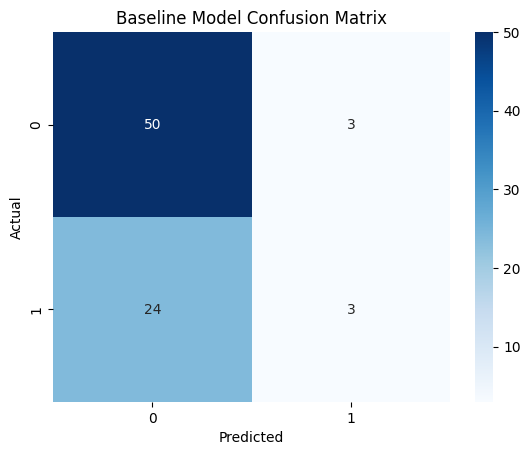

In [64]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
# Feature Engineering (Model Enhancement/Improvement Step)

# Create Interaction feature

df['GRE_GPA'] = df['gre'] * df['gpa']

In [66]:
# Define Features Again

X = df.drop('admit', axis=1)
y = df['admit']

In [67]:
# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
# Train Test Split again

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [69]:
# Improved Models

# Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.625


In [70]:
# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6875


In [71]:
# Hyperparameter Tuning

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,5,10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

In [72]:
# Improved Model Accuracy

y_pred_best = best_model.predict(X_test)
improved_accuracy = accuracy_score(y_test, y_pred_best)
print("Improved Accuracy:", improved_accuracy)

Improved Accuracy: 0.6375


In [73]:
# Accuracy Improvement

improvement = ((improved_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print("Accuracy Improvement:", improvement, "%")

Accuracy Improvement: -3.7735849056603805 %


## Feature Engineering Result and Next Improvement Step

After introducing the engineered feature **GRE_GPA (gre × gpa)**, the model accuracy decreased from **0.6625 (baseline)** to **0.6375**. This indicates that the newly created feature did not provide additional useful information for the model and may have introduced noise or redundancy, slightly reducing predictive performance.

To address this, the next step is to apply **feature scaling using StandardScaler with Logistic Regression**. Logistic Regression models often perform better when input features are normalized, as scaling ensures that variables such as GRE and GPA contribute proportionally during model training and helps the optimization algorithm converge more effectively.

In [74]:
# Removing the engineered feature 

df.drop('GRE_GPA', axis=1, inplace=True)

In [75]:
# Use logistic Regression with scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
# Tune Logistic Regression

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

In [77]:
# Evaluate again

y_pred = best_model.predict(X_test)
improved_accuracy = accuracy_score(y_test, y_pred)

In [78]:
# Improved Model Accuracy

y_pred_best = best_model.predict(X_test)
improved_accuracy = accuracy_score(y_test, y_pred_best)
print("Improved Accuracy:", improved_accuracy)

Improved Accuracy: 0.675


In [79]:
# Accuracy Improvement

improvement = ((improved_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print("Accuracy Improvement:", improvement, "%")

Accuracy Improvement: 1.8867924528301987 %


## Improved Model Result

After applying **feature scaling using StandardScaler with Logistic Regression**, the model accuracy improved to **0.675**, compared to the baseline accuracy of **0.6625**.

This improvement indicates that scaling the input features helped the Logistic Regression algorithm perform better by ensuring that variables such as GRE and GPA are on a similar numerical scale. Proper feature scaling improves the optimization process and allows the model to learn more balanced feature contributions.

In [80]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Logistic Regression + Feature Engineering",
        "Logistic Regression + Feature Scaling"
    ],
    "Accuracy": [
        0.6625,
        0.6375,
        0.675
    ]
})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.6625
1,Logistic Regression + Feature Engineering,0.6375
2,Logistic Regression + Feature Scaling,0.6750


## Model Comparison

Three model variations were evaluated during the improvement process. 
The baseline Logistic Regression model achieved an accuracy of **0.6625**. 
Feature engineering using the GRE_GPA interaction feature slightly reduced the accuracy to **0.6375**, indicating that the engineered feature did not improve predictive performance.

After applying **feature scaling with StandardScaler**, the Logistic Regression model achieved the highest accuracy of **0.675**, showing a modest improvement over the baseline model.

In [81]:
# Accuracy Improvement calculation

baseline_accuracy = 0.6625
improved_accuracy = 0.675
improvement = ((improved_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print("Accuracy Improvement:", improvement, "%")

Accuracy Improvement: 1.8867924528301987 %


## Accuracy Improvement

The baseline model achieved an accuracy of **0.6625**, while the improved model using feature scaling achieved an accuracy of **0.675**.

This represents an improvement of approximately **1.89%**, indicating that feature scaling helped the Logistic Regression model perform slightly better by normalizing the input features.

## Interpretation of Improved Model

The improvement in model accuracy after feature scaling suggests that Logistic Regression benefits from normalized input features. Since GRE and GPA are on different numerical scales, scaling ensures that both variables contribute proportionally during model training.

Although the improvement is modest, it demonstrates that proper preprocessing techniques such as feature scaling can enhance model performance and stability.

## Final Business Insights

The model shows that GRE scores, GPA, and university rank collectively influence admission decisions. By using this predictive model, universities can estimate the probability of student admission based on academic performance indicators.

Such models can assist admission committees in screening large numbers of applications more efficiently while maintaining consistency in evaluation.

## Conclusion

This project successfully improved the baseline admission prediction model by applying feature engineering and preprocessing techniques. While the initial feature engineering attempt did not improve performance, applying feature scaling with Logistic Regression resulted in a modest accuracy improvement.

The final model achieved an accuracy of **0.675**, representing an improvement over the baseline model. This highlights the importance of preprocessing and experimentation in developing more effective machine learning models.